In [1]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
%matplotlib inline

In [12]:
df=pd.read_csv('/content/Advertising.csv')
df.drop(columns=df.columns[0], axis=1,  inplace=True)

df.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [14]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [15]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

<Axes: >

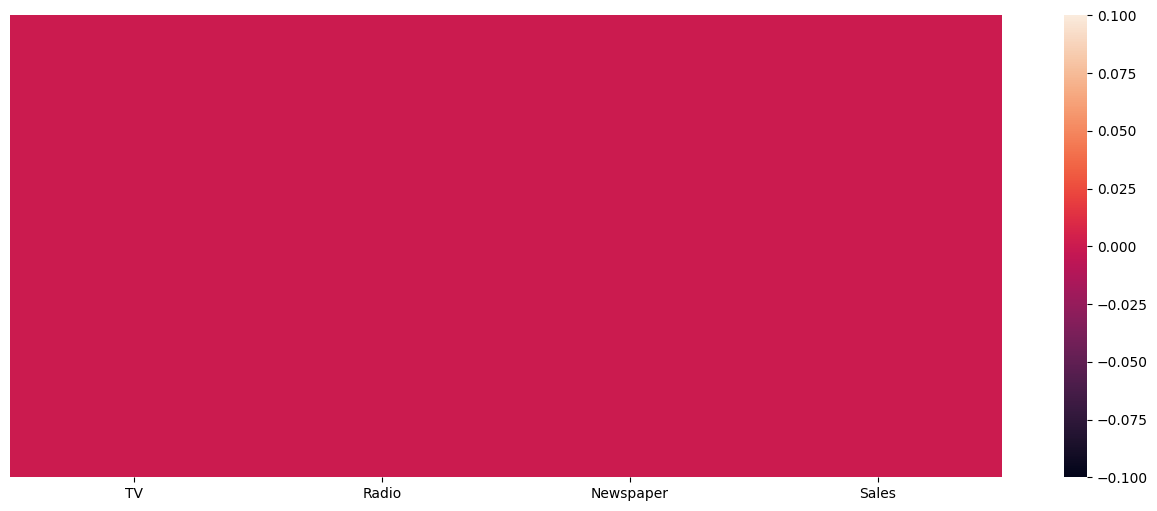

In [57]:
import seaborn as sns
plt.figure(figsize=(16,6))
sns.heatmap(df.isna(),yticklabels=False)

Text(0.5, 1.0, 'Scatter Plot')

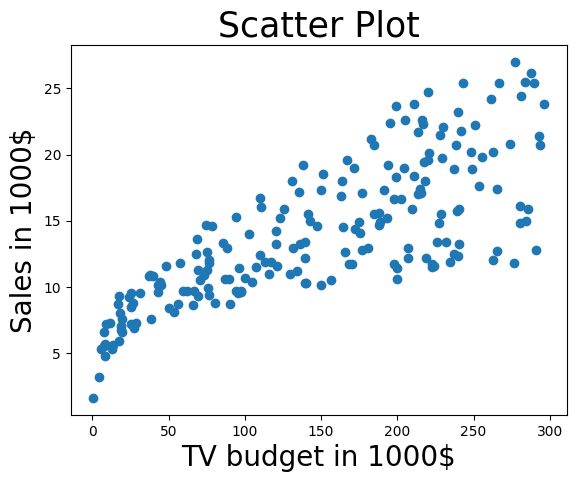

In [22]:
# Select variables and draw a scatter Plot
x=df['TV'].values # predictor
y=df['Sales'].values #response or output variable
plt.scatter(x,y)
plt.xlabel('TV budget in 1000$' ,fontsize=20)
plt.ylabel('Sales in 1000$',fontsize=20)
plt.title('Scatter Plot',fontsize=25)

In [23]:
#Split Data set
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7)

In [45]:
k_list=np.arange(1,80,1)
knn_dict={} # To store k and mse pairs
for i in k_list:
#Knn Model Creation
    knn=KNeighborsRegressor(n_neighbors=int(i))
    model_knn=knn.fit(np.array(x_train).reshape(-1,1),y_train)
    y_knn_pred=model_knn.predict(np.array(x_test).reshape(-1,1))
#Storing MSE
    mse=mean_squared_error(y_test,y_knn_pred)
    knn_dict[i]=mse

Text(0.5, 1.0, 'ELBOW PLOT')

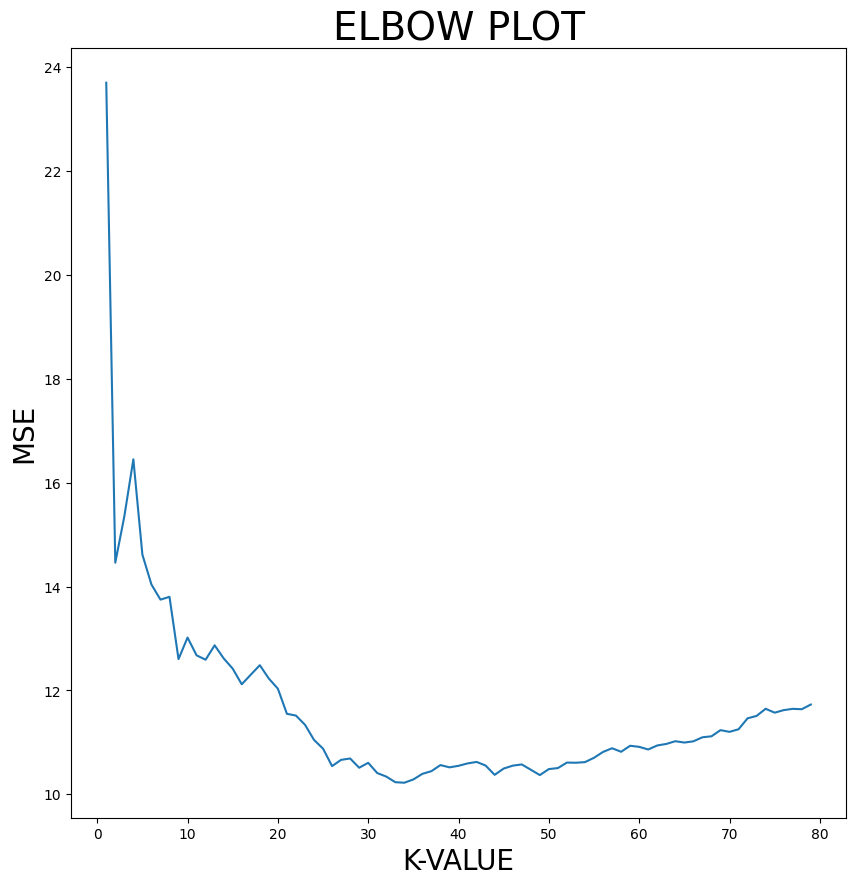

In [30]:
#Plotting the results
fig,ax=plt.subplots(figsize=(10,10))
ax.plot(knn_dict.keys(),knn_dict.values())
ax.set_xlabel('K-VALUE', fontsize=20)
ax.set_ylabel('MSE' ,fontsize=20)
ax.set_title('ELBOW PLOT' ,fontsize=28)

In [52]:
l=min(knn_dict.values())
key = [k for k, v in knn_dict.items() if v == l]
key[0]

34

In [53]:
knn_min=KNeighborsRegressor(n_neighbors=key[0])
model_knn=knn_min.fit(np.array(x_train).reshape(-1,1),y_train)


In [55]:
y_knn_pred=knn_min.predict(np.array(x_test).reshape(-1,1))

In [56]:
mse=mean_squared_error(y_test,y_knn_pred)
mse

10.22343800461361